#### *Performance Metrics Calculation*
##### Implementation of PSNR, SSIM and Histogram plot to evaluate the quality of a stego-image against the original cover image for Basic LSB.

PSNR: 45.0578 dB
SSIM: 0.9943


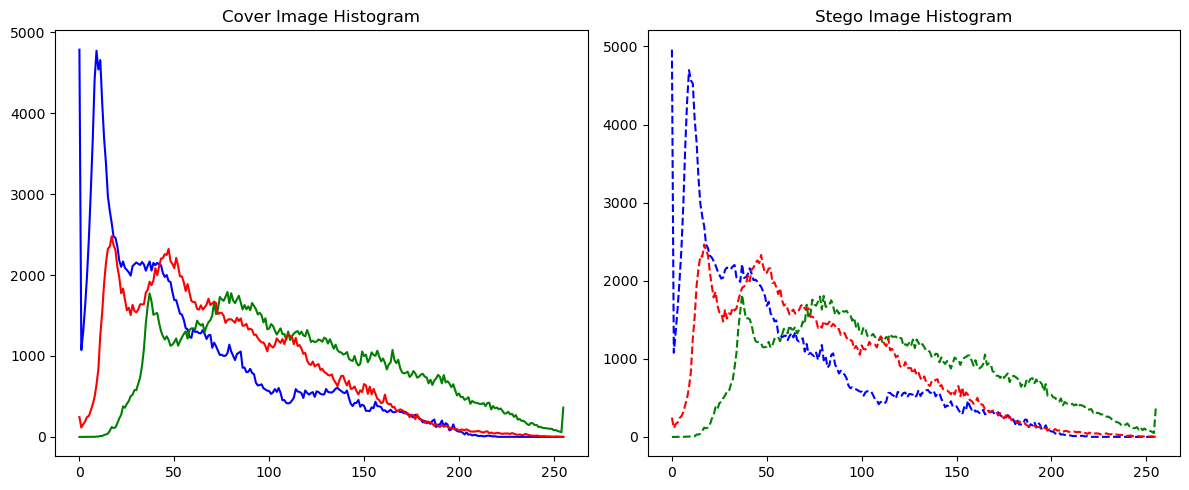

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

def calculate_psnr(cover_img, stego_img):
    # Convert to float64 to prevent overflow errors during subtraction
    cover = cover_img.astype(np.float64)
    stego = stego_img.astype(np.float64)
    
    mse = np.mean((cover - stego) ** 2)
    if mse == 0:
        return float('inf') # No noise; images are identical
    
    max_pixel = 255.0
    psnr_val = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr_val

def calculate_ssim(cover_img, stego_img):
    # For color images, set channel_axis=-1
    if len(cover_img.shape) == 3:
        return ssim(cover_img, stego_img, channel_axis=-1)
    else:
        return ssim(cover_img, stego_img)

def plot_histogram_analysis(cover_img, stego_img):
    plt.figure(figsize=(12, 5))
    
    # Check if the image is grayscale or color
    if len(cover_img.shape) == 2:
        # Grayscale Histogram
        plt.subplot(1, 2, 1)
        plt.hist(cover_img.ravel(), bins=256, range=[0,256], color='blue', alpha=0.5, label='Cover')
        plt.hist(stego_img.ravel(), bins=256, range=[0,256], color='red', alpha=0.5, label='Stego')
        plt.title('Grayscale Histogram Comparison')
        plt.xlabel('Pixel Intensity')
        plt.ylabel('Frequency')
        plt.legend()
    else:
        # Color Histogram (showing only one channel or flattened for brevity)
        colors = ('b', 'g', 'r')
        for i, col in enumerate(colors):
            hist_cover = cv2.calcHist([cover_img], [i], None, [256], [0, 256])
            hist_stego = cv2.calcHist([stego_img], [i], None, [256], [0, 256])
            
            plt.subplot(1, 2, 1)
            plt.plot(hist_cover, color=col, linestyle='-', label=f'Cover {col.upper()}')
            plt.title('Cover Image Histogram')
            
            plt.subplot(1, 2, 2)
            plt.plot(hist_stego, color=col, linestyle='--', label=f'Stego {col.upper()}')
            plt.title('Stego Image Histogram')
            
    plt.tight_layout()
    plt.show()

# --- Execution Workflow ---
if __name__ == "__main__":
    # Load your images (ensure they are the exact same dimensions)
    # paths should point to your standard LSB output images
    cover = cv2.imread('input_image.jpg')
    stego = cv2.imread('encoded_image.png')
    
    if cover is None or stego is None:
        print("Error: Could not load images. Check your file paths.")
    else:
        # 1. Compute PSNR
        psnr_value = calculate_psnr(cover, stego)
        print(f"PSNR: {psnr_value:.4f} dB")
        
        # 2. Compute SSIM
        ssim_value = calculate_ssim(cover, stego)
        print(f"SSIM: {ssim_value:.4f}")
        
        # 3. Generate Histogram Analysis
        plot_histogram_analysis(cover, stego)